# **Mestrado em Ciência de Dados - 2.º Ano**
**Aluno:** Miguel Loureiro | 2220134

**Instituição:** Universidade de Leiria e Oeste  

***Dissertação:*** Data Mining Aplicado à Transformação Digital de uma PME Portuguesa de E-commerce: Um Caso de Estudo Integrado

---

# **Notebook 7. Clustering | K-Means RFM - Segmentação de Clientes por Valor e Ciclo de Vida**
*O presente notebook engloba um problema de clustering aplicado à segmentação de clientes por ciclo de vida, com base nas variáveis RFM (Recency, Frequency, Monetary).*

---

## **Contextualização do problema em estudo**

### **Problema de negócio**

Identificar segmentos de clientes de acordo com a fase do seu ciclo de vida em relação à empresa, permitindo diferenciar clientes **Champions** (clientes ativos de elevado valor para a empresa), clientes **Regulares** (clientes ativos de valor moderado), clientes **Ocasionais** (clientes com atividade esporádica) e clientes **Adormecidos** (clientes em risco de abandono por um período longo de inatividade). Esta segmentação visa direcionar a tomada de decisão sustentada em dados para definir campanhas de retenção, reativação e fidelização.

### **Formulação do problema de Clustering RFM**

**Tarefa:** Clustering aplicado às três variáveis RFM (Recency, Frequency e Monetary) criadas previamente com vista à identificação de grupos organizados por fase do ciclo de vida do cliente.

**Dimensão:** Clientes recorrentes com pelo menos 2 compras, englobando os 5.521 clientes utilizados nos notebooks 5 e 6.

**Features:**
- **Recency** - número de dias desde a última compra.
- **Frequency** - número total de compras realizadas pelo cliente.
- **Monetary** - valor total gasto pelo cliente em euros.

As três variáveis RFM são reutilizadas a partir do `df_clientes_enriquecido` desenvolvido e exportado no NB2.

**Métrica principal:** Silhouette Score em conjunto com a análise da curva Elbow (WCSS) para a seleção de k (número de clusters).

### **Algoritmo aplicado**

| Algoritmo | Tipo | Justificação |
|---|---|---|
| **K-Means** | Baseado em centróides | Algoritmo de referência para clustering RFM na literatura, que produz segmentos compactos e bem separados. |

### **Caracterização do notebook**

Este notebook representa o último dos três notebooks da componente de clustering, englobando a aplicação do algoritmo K-Means sobre as três variáveis RFM, criando uma segmentação baseada no ciclo de vida.

### **Boas práticas adotadas**

- **Reutilização integral das variáveis RFM do `df_clientes_enriquecido`**, eliminando a duplicação de passos.
- **Filtro de pelo menos 2 compras**, garantindo coerência com os dois notebooks anteriores (NB5 e NB6).
- **Determinação do k ótimo conjugando Elbow e Silhouette Score**.
- **Caracterização dos clusters em valores reais**, facilitando a interpretação operacional.

---

## **Estrutura do notebook**

1. Importação de bibliotecas
2. Carregamento dos dados
3. Construção do dataset RFM
4. Filtragem do universo - clientes recorrentes (2+ compras)
5. Normalização
6. Determinação do k ótimo - Elbow + Silhouette Score
7. Treino do modelo final
8. Caracterização dos clusters
   - 8.1. Perfil médio em valores reais
   - 8.2. Heatmap dos perfis (z-score)
   - 8.3. Dimensão de cada cluster
9. Visualização - scatter plots
10. Cruzamento com a segmentação de portfólio (NB5)
11. Exportação
12. Síntese

### **Outputs deste notebook**

- **`dataset_clusters_rfm.csv`** - atribuição de cluster RFM por `Ref Cliente`.
- **`kmeans_rfm.pkl`** - modelo K-Means RFM e scaler.


## **1. Importação de bibliotecas**

Este notebook inicia-se com a importação das bibliotecas que permitem a aplicação de K-Means RFM.

In [ ]:
#Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

#Pré-processamento e algoritmo
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## **2. Carregamento dos dados**

Os dados são carregados a partir do `df_clientes_enriquecido` que foi desenvolvido no NB2 e que engloba as três variáveis RFM (`Recency`, `Frequency`, `Monetary`) criadas tendo em conta todo o histórico do cliente.

In [ ]:
#Montar Drive e carregar o dataset
from google.colab import drive
drive.mount('/content/drive')

#df_clientes_enriquecido - já contém Recency, Frequency e Monetary do NB2
df_clientes = pd.read_csv(
    '/content/drive/MyDrive/df_clientes_enriquecido.csv'
)[['Ref Cliente', 'Recency', 'Frequency', 'Monetary']]   #apenas necessário as 4 colunas (Ref Cliente + RFM)

print(f'df_clientes_enriquecido (subset RFM): {df_clientes.shape}')

#Confirmação defensiva - as três variáveis RFM devem estar presentes
assert 'Recency' in df_clientes.columns, 'Recency ausente - verificar export do NB2'
assert 'Frequency' in df_clientes.columns, 'Frequency ausente - verificar export do NB2'
assert 'Monetary' in df_clientes.columns, 'Monetary ausente - verificar export do NB2'

print(f'\nEstatísticas descritivas das variáveis RFM:')
print(df_clientes[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
df_clientes_enriquecido (subset RFM): (13074, 4)

Estatísticas descritivas das variáveis RFM:
        Recency  Frequency  Monetary
count  13074.00   13074.00  13074.00
mean    1256.80       4.28    292.15
std      995.59       9.56    849.57
min        0.00       1.00      2.40
25%      300.00       1.00     35.40
50%     1117.50       1.00     68.70
75%     2063.00       3.00    192.50
max     3699.00     174.00  18431.09


## **3. Construção do *dataset* RFM**

Segue-se a criação do dataset RFM indexado pela variável `Ref Cliente`, assim como a remoção de eventuais registos com valores omissos.

In [ ]:
#Construir o dataset RFM com as 3 variáveis canónicas (Recency, Frequency, Monetary)
df_rfm = df_clientes.set_index('Ref Cliente')[['Recency', 'Frequency', 'Monetary']].copy()

#Remover linhas com valores em falta (qualquer cliente sem RFM completo)
df_rfm = df_rfm.dropna()

print(f'Dimensão do dataset RFM: {df_rfm.shape}')
print(f'\nEstatísticas descritivas:')
print(df_rfm.describe().round(2))

Dimensão do dataset RFM: (13074, 3)

Estatísticas descritivas:
        Recency  Frequency  Monetary
count  13074.00   13074.00  13074.00
mean    1256.80       4.28    292.15
std      995.59       9.56    849.57
min        0.00       1.00      2.40
25%      300.00       1.00     35.40
50%     1117.50       1.00     68.70
75%     2063.00       3.00    192.50
max     3699.00     174.00  18431.09


A análise às estatísticas descritivas permite constatar que não existem valores omissos no conjunto de dados em utilização e comprovar que a dimensão do dataset é constituída por 13.074 linhas e 3 colunas.

## **4. Filtragem do universo - clientes recorrentes (2+ compras)**

Mantendo a coerência com a metodologia aplicada nos NB5 e NB6, é aplicado o filtro da base de clientes de forma a incluir apenas clientes com pelo menos 2 compras.

In [ ]:
#Guardar a versão completa
df_rfm_todos = df_rfm.copy()

#Filtrar para reter apenas clientes recorrentes
df_rfm = df_rfm[df_rfm['Frequency'] >= 2].copy()

n_total = len(df_rfm_todos)
n_recorrentes = len(df_rfm)
n_excluidos = n_total - n_recorrentes

print(f'Clientes na base completa:           {n_total}')
print(f'Clientes com 1 compra (excluídos):    {n_excluidos}')
print(f'Clientes recorrentes (mantidos):      {n_recorrentes}')
print(f'\nProporção do universo filtrado: {n_recorrentes/n_total:.1%}')
print(f'\nEstatísticas descritivas (clientes recorrentes):')
print(df_rfm.describe().round(2))

Clientes na base completa:           13074
Clientes com 1 compra (excluídos):    7553
Clientes recorrentes (mantidos):      5521

Proporção do universo filtrado: 42.2%

Estatísticas descritivas (clientes recorrentes):
       Recency  Frequency  Monetary
count  5521.00    5521.00   5521.00
mean    983.61       8.77    614.62
std     891.76      13.48   1234.45
min       0.00       2.00      9.80
25%     132.00       2.00    108.40
50%     783.00       4.00    222.92
75%    1616.00       9.00    587.21
max    3578.00     174.00  18431.09


A aplicação do filtro resulta numa redução da base de clientes de 13.074 para 5.521 clientes recorrentes, correspondendo a 42,2% da totalidade dos clientes.

## **5. Normalização**

As três variáveis RFM apresentam escalas distintas, como Recency em dias, Frequency em número de compras e Monetary em euros. Desta forma, é aplicado `StandardScaler` para assegurar que todas as variáveis apresentem a mesma escala (média = 0, variância = 1).

In [ ]:
#Normalização das features RFM
scaler = StandardScaler()
X = scaler.fit_transform(df_rfm)

print(f'Dimensão de X após normalização: {X.shape}')
print(f'Features: {list(df_rfm.columns)}')

Dimensão de X após normalização: (5521, 3)
Features: ['Recency', 'Frequency', 'Monetary']


A validação da dimensão do dataset comprova a permanência de 5.521 linhas e 3 features.

## **6. Determinação do k ótimo - Elbow + Silhouette**

O número de clusters a selecionar é realizado recorrendo à conjugação da análise ao método Elbow (WCSS) e ao Silhouette Score, sendo ambos calculados para valores de k entre 2 e 10, garantindo que não é tido em conta apenas 1 cluster, mas também não será considerado um número excessivamente de clusters (>10).

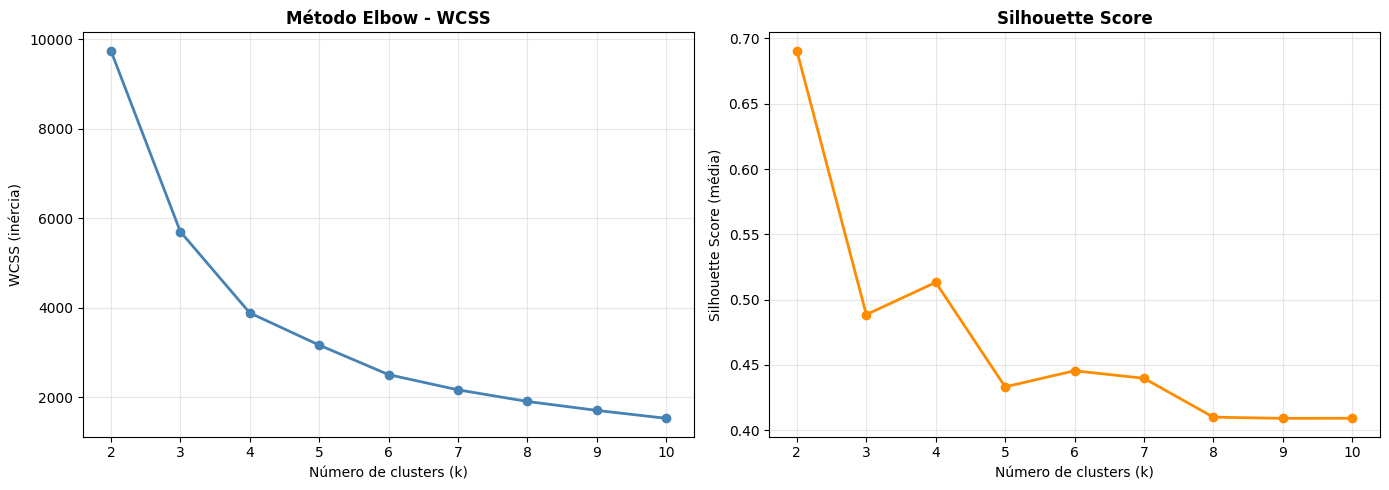


Valores numéricos:
  k=2: WCSS =  9739.06  |  Silhouette = 0.6906
  k=3: WCSS =  5700.90  |  Silhouette = 0.4886
  k=4: WCSS =  3887.01  |  Silhouette = 0.5132
  k=5: WCSS =  3168.31  |  Silhouette = 0.4333
  k=6: WCSS =  2508.69  |  Silhouette = 0.4456
  k=7: WCSS =  2169.50  |  Silhouette = 0.4398
  k=8: WCSS =  1909.91  |  Silhouette = 0.4101
  k=9: WCSS =  1710.77  |  Silhouette = 0.4092
  k=10: WCSS =  1533.53  |  Silhouette = 0.4092

k com maior Silhouette: 2


In [ ]:
#Calcular WCSS e Silhouette Score para k entre 2 e 10
ks = range(2, 11)
wcss = []
silhouettes = []

for k in ks:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X)
    wcss.append(modelo.inertia_)
    silhouettes.append(silhouette_score(X, labels))

#Visualizar Elbow e Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(ks), wcss, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Método Elbow - WCSS', fontweight='bold')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('WCSS (inércia)')
axes[0].set_xticks(list(ks))
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(ks), silhouettes, marker='o', linewidth=2, color='darkorange')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score (média)')
axes[1].set_xticks(list(ks))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nValores numéricos:')
for k, w, s in zip(ks, wcss, silhouettes):
    print(f'  k={k}: WCSS = {w:8.2f}  |  Silhouette = {s:.4f}')

print(f'\nk com maior Silhouette: {list(ks)[silhouettes.index(max(silhouettes))]}')

**Interpretação dos critérios de seleção do k**

Os resultados obtidos são apresentados de seguida:

| k | WCSS | Silhouette Score |
|---|---|---|
| 2 | 9.739,06 | **0,6906** |
| 3 | 5.700,90 | 0,4886 |
| **4** | **3.887,01** | **0,5132** |
| 5 | 3.168,31 | 0,4333 |
| 6 | 2.508,69 | 0,4456 |
| 7 | 2.169,50 | 0,4398 |
| 8 | 1.909,91 | 0,4101 |
| 9 | 1.710,77 | 0,4092 |
| 10 | 1.533,53 | 0,4092 |

A análise aos valores registados evidencia que em k=2 é obtido o maior Silhouette Score (0,6906), no entanto a escolha por esta constituição apenas contribuiria para diferenciar clientes ativos de inativos, não permitindo extrair conhecimento realmente acionável para a estratégia de marketing.

Como tal, é selecionado **k=4**, situação em que se verifica o segundo Silhouette Score mais elevado (**0,5132**). Esta constituição contribui para obter uma estrutura de segmentos mais rica em informação acionável, na medida em que permite separar as quatro fases mais relevantes do ciclo de vida do cliente, nomeadamente, clientes Champions, Regulares, Ocasionais, Adormecidos, estando ainda alinhada com literatura.

## **7. Treino do modelo final**

De seguida, é treinado o modelo com k=4, permitindo separar a base de clientes recorrentes em quatro clusters distintos.

In [ ]:
#Definir k_otimo
k_otimo = 4

#Treinar KMeans RFM final
modelo_kmeans_rfm = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
df_rfm['Cluster'] = modelo_kmeans_rfm.fit_predict(X)

#Reportar Silhouette final e distribuição
silhouette_final = silhouette_score(X, df_rfm['Cluster'])
print(f'Silhouette Score do modelo final (k={k_otimo}): {silhouette_final:.4f}')
print(f'\nDistribuição dos clientes por cluster:')
print(df_rfm['Cluster'].value_counts().sort_index())

Silhouette Score do modelo final (k=4): 0.5132

Distribuição dos clientes por cluster:
Cluster
0    2999
1    1928
2      81
3     513
Name: count, dtype: int64


O modelo final distribui a base de clientes recorrentes em quatro clusters de dimensões variáveis, sendo que o Cluster 0 apresenta a maior dimensão (2.999) e o Cluster 2 a menor dimensão (81).

## **8. Caracterização dos *clusters***

Com o intuito de caracterizar os quatro clusters obtidos, recorre-se à análise do perfil médio por cliente através de valores reais, ao heatmap e à análise da distribuição dos clusters.

### **8.1. Perfil médio por cluster (valores reais)**

In [ ]:
#Perfil médio em valores reais
perfil_real = df_rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
perfil_real.columns = ['Recency (dias)', 'Frequency (compras)', 'Monetary (€)']

print('Perfil médio dos clusters (valores reais):')
print(perfil_real)

#Adicionar dimensão
tamanhos = df_rfm['Cluster'].value_counts().sort_index()
proporcoes = df_rfm['Cluster'].value_counts(normalize=True).sort_index() * 100

perfil_completo = perfil_real.copy()
perfil_completo['N Clientes'] = tamanhos
perfil_completo['% Base'] = proporcoes.round(1).astype(str) + '%'

print(f'\nPerfil completo (com dimensão):')
print(perfil_completo)

Perfil médio dos clusters (valores reais):
         Recency (dias)  Frequency (compras)  Monetary (€)
Cluster                                                   
0                456.97                 5.90        369.67
1               2031.38                 4.05        212.35
2                111.63                82.43       7989.50
3                262.24                31.69       2393.96

Perfil completo (com dimensão):
         Recency (dias)  Frequency (compras)  Monetary (€)  N Clientes % Base
Cluster                                                                      
0                456.97                 5.90        369.67        2999  54.3%
1               2031.38                 4.05        212.35        1928  34.9%
2                111.63                82.43       7989.50          81   1.5%
3                262.24                31.69       2393.96         513   9.3%


### **8.2. Heatmap dos perfis (z-score)**

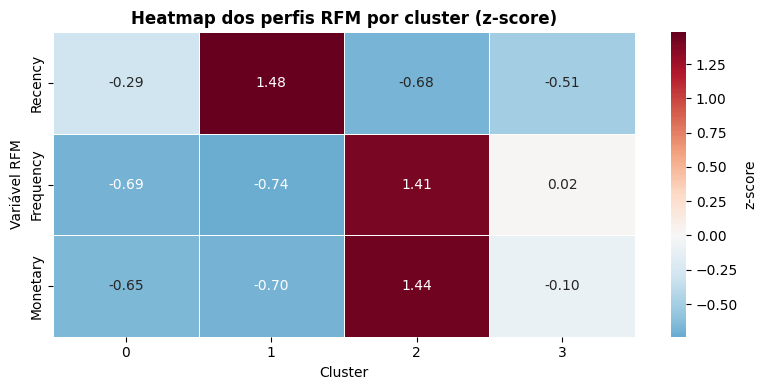

In [ ]:
#Calcular perfil médio em z-score
perfil_norm = df_rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
perfil_zscore = (perfil_norm - perfil_norm.mean()) / perfil_norm.std()

#Heatmap dos perfis normalizados
plt.figure(figsize=(8, 4))
sns.heatmap(
    perfil_zscore.T,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'z-score'}
)
plt.title('Heatmap dos perfis RFM por cluster (z-score)', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Variável RFM')
plt.tight_layout()
plt.show()

### **8.3. Dimensão de cada cluster**

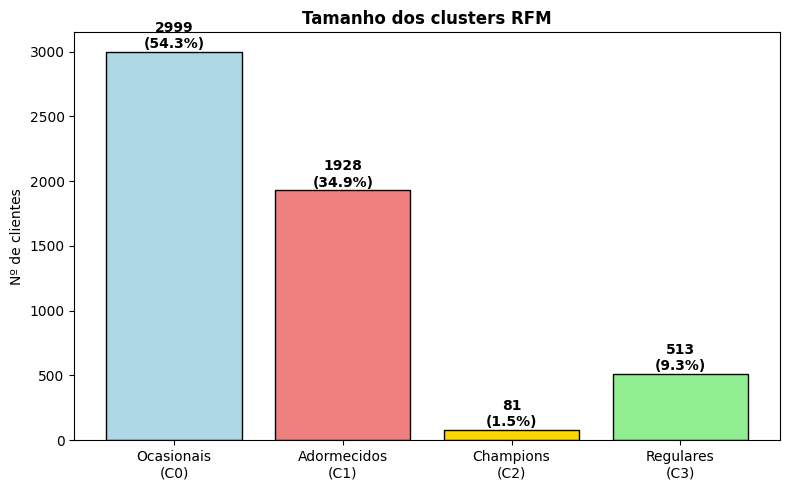


Proporção de clientes por cluster:
Cluster
0    54.32%
1    34.92%
2     1.47%
3     9.29%
Name: proportion, dtype: object


In [ ]:
#Visualização da dimensão de cada cluster
tamanhos = df_rfm['Cluster'].value_counts().sort_index()
proporcoes = df_rfm['Cluster'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 5))
nomes_clusters = ['Ocasionais\n(C0)', 'Adormecidos\n(C1)', 'Champions\n(C2)', 'Regulares\n(C3)']
plt.bar(nomes_clusters, tamanhos.values, color=['lightblue', 'lightcoral', 'gold', 'lightgreen'], edgecolor='black')

plt.title('Tamanho dos clusters RFM', fontweight='bold')
plt.ylabel('Nº de clientes')
for i, (n, p) in enumerate(zip(tamanhos.values, proporcoes.values)):
    plt.text(i, n + 30, f'{n}\n({p:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nProporção de clientes por cluster:')
print(df_rfm['Cluster'].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + '%')

**Caracterização dos clusters**

A partir dos valores reais, identificam-se os quatro arquétipos canónicos do modelo RFM:

**Cluster 0 - "Clientes Ocasionais"** (n=2.999, 54,32%) - É o cluster dominante, representando mais de metade da base de clientes recorrentes. Este segmento apresenta Recency 457 dias, Frequency 5,9, Monetary 369,67€. A estratégia recomendada para este cluster passa pela estimulação de frequência.

**Cluster 1 - "Clientes Adormecidos"** (n=1.928, 34,92%) - Representa o segundo grupo mais numeroso de clientes e apresenta Recency 2.031 dias (~5,5 anos), Frequency 4,1, Monetary 212,35€. A estratégia recomendada para este cluster deve contemplar campanhas win-back de forma a conseguir voltar a estabelecer uma relação com alguns destes clientes.

**Cluster 2 - "Champions"** (n=81, 1,47%) - Cluster menos numeroso, mais com maior valor acrescentado para a empresa, englobando apenas 1,5% da base, mas com Recency 112 dias, Frequency 82,4 compras e Monetary 7.989,50€. A equipa de marketing deve focar os seus esforços no envolvimento e retenção destes clientes, pois a perda de um deles pode representar uma queda representativa na receita da empresa.

**Cluster 3 - "Clientes Regulares"** (n=513, 9,29%) - Segmento de reduzida dimensão constituído por clientes ativos leais, apresentando Recency 262 dias, Frequency 31,7 e Monetary 2.393,96€. As recomendações estratégicas englobam o foco em ações de retenção e de crescimento.

## **9. Visualização**

A apresentação dos scatter plots serve para visualizar  o nível de separação dos clusters através de duas representações: Frequency vs Monetary e Recency vs Monetary.

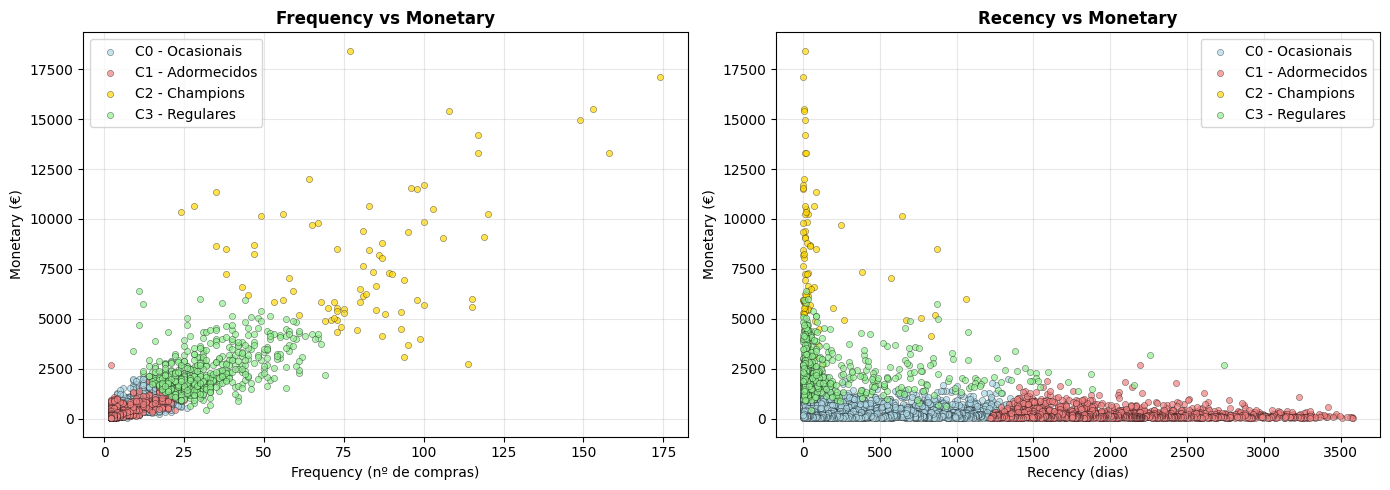

In [ ]:
#Dois scatter plots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = {0: 'lightblue', 1: 'lightcoral', 2: 'gold', 3: 'lightgreen'}
nomes = {0: 'Ocasionais', 1: 'Adormecidos', 2: 'Champions', 3: 'Regulares'}

#Scatter 1: Frequency vs Monetary
for c in sorted(df_rfm['Cluster'].unique()):
    mask = df_rfm['Cluster'] == c
    axes[0].scatter(df_rfm.loc[mask, 'Frequency'], df_rfm.loc[mask, 'Monetary'],
                    s=20, c=cores[c], label=f'C{c} - {nomes[c]}', alpha=0.7, edgecolors='black', linewidth=0.3)
axes[0].set_title('Frequency vs Monetary', fontweight='bold')
axes[0].set_xlabel('Frequency (nº de compras)')
axes[0].set_ylabel('Monetary (€)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

#Scatter 2: Recency vs Monetary
for c in sorted(df_rfm['Cluster'].unique()):
    mask = df_rfm['Cluster'] == c
    axes[1].scatter(df_rfm.loc[mask, 'Recency'], df_rfm.loc[mask, 'Monetary'],
                    s=20, c=cores[c], label=f'C{c} - {nomes[c]}', alpha=0.7, edgecolors='black', linewidth=0.3)
axes[1].set_title('Recency vs Monetary', fontweight='bold')
axes[1].set_xlabel('Recency (dias)')
axes[1].set_ylabel('Monetary (€)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretação dos scatter plots**

A observação das representações gráficas permite constatar que no:
- **Scatter Frequency vs Monetary** o Cluster 2, que representa os clientes Champions na cor amarela, está concentrado no canto superior direito com elevados valores de frequência de compras e alto valor gasto, enquanto o Cluster 3, composto pelos clientes Regulares, se concentra na zona intermédia. Os restantes clusters (0 - Ocasionais e 1 - Adormecidos) estão sobrepostos no canto inferior esquerdo, representandos por baixa frequência de compras e baixo valor total gasto.

- **Scatter Recency vs Monetary** a variável Recency separa, de forma clara, os clientes Adormecidos (Cluster 1) na cor vermelha dos restantes pela sua elevada concentração à direita correspondendo a um elevado número de dias desde a última compra. Os clientes Champions (Cluster 2) e Regulares (Cluster 3) destacam-se no canto superior esquerdo, indicando que compraram recentemente (Recency reduzida) e gastaram muito (Monetary elevada).

## **10. Cruzamento com a segmentação de portfólio (NB5)**

A validação cruzada entre os clusters RFM (ciclo de vida) e os clusters de portfólio do K-Means identificados no NB5 permite verificar o nível de complementaridade entre as duas abordagens analíticas.

In [ ]:
#Carregar clusters de portfólio do NB6
df_kmeans_portfolio = pd.read_csv(
    '/content/drive/MyDrive/dataset_clusters_kmeans.csv',
    index_col=0
)

#Cruzar atribuições dos dois métodos
comparacao = pd.DataFrame({
    'Cluster_Portfolio': df_kmeans_portfolio['Cluster'],
    'Cluster_RFM':       df_rfm['Cluster']
}).dropna().astype(int)

print(f'Clientes na interseção dos dois universos: {len(comparacao)}')

#Tabela de contingência Portfólio × RFM
tabela = pd.crosstab(
    comparacao['Cluster_Portfolio'],
    comparacao['Cluster_RFM'],
    margins=True,
    margins_name='Total'
)
print('\nTabela de contingência - Clusters de Portfólio (NB5) vs Clusters RFM')
print('(número de clientes em cada combinação)')
print(tabela)

Clientes na interseção dos dois universos: 5521

Tabela de contingência - Clusters de Portfólio (NB5) vs Clusters RFM
(número de clientes em cada combinação)
Cluster_RFM           0     1   2    3  Total
Cluster_Portfolio                            
0                  1702  1022   0   54   2778
1                   692   591   0   69   1352
2                   120    22   0    9    151
3                   107    27  81  360    575
4                    13    37   0    0     50
5                   339   140   0   21    500
6                    26    89   0    0    115
Total              2999  1928  81  513   5521


**Interpretação da validação cruzada**

A tabela de contingência apresentada permite cruzar a base dos 5.521 clientes recorrentes entre as duas abordagens de clustering utilizadas com K-Means.

Os resultados obtidos evidenciam a complementaridade entre as duas segmentações, sendo que em cada cluster de portfólio, verifica-se que os clientes se distribuem por múltiplos clusters RFM, indicando que não existe uma concentração numa única célula por linha. Desta forma, constata-se que a compreensão do portfólio não é suficiente para identificar o ciclo de vida do cliente, e vice-versa.

A conclusão mais relevante assenta no facto de todos os 81 clientes Champions (Cluster 2 na abordagem RFM) estarem concentrados somente no cluster de Avicultores VIP (Cluster 3 na abordagem portfólio no NB5). Como tal, os resultados demonstram que os clientes Champions se traduzem em avicultores que diversificam o seu portfólio.

Com base nestas evidências, a empresa em estudo deve focar as suas ações de retenção nos clientes Champions do segmento avícola mais diversificado, tendo em consideração que um avicultor que opta por também comprar produtos de outras categorias representa um sinal positivo de fidelização. Neste sentido, este tipo de clientes deve ser identificado, envolvido e recompensado antes de poder ser captado por um concorrente.

Adicionalmente, o segmento de Avicultores VIP (Cluster 3), constituído por 575 clientes, identificado no NB5 engloba os 81 Champions (14,1%), 360 Regulares (62,6%), 107 Ocasionais (18,6%) e 27 Adormecidos (4,7%). Com base na sua constituição, trata-se de um cluster bastante heterogéneo em termos de ciclo de vida, pois integra clientes Champions com Adormecidos em risco de abandono.

A combinação das duas segmentações desenvolvidas permite, assim, melhorar a tomada de decisão relativamente às campanhas personalizadas a dirigir a cada interseção específica.

## **11. Exportação**

O presente notebook termina com a exportação de dois outputs:

- **`dataset_clusters_rfm.csv`** - dataframe com as três variáveis RFM e o atributo `Cluster`.
- **`kmeans_rfm.pkl`** - inclui o modelo K-Means RFM e scaler.

In [ ]:
#Exportar dataset com clusters RFM atribuídos
df_rfm.to_csv('/content/drive/MyDrive/dataset_clusters_rfm.csv')
print('Dataset exportado: dataset_clusters_rfm.csv')

#Garantir que a pasta /modelos existe
os.makedirs('/content/drive/MyDrive/modelos', exist_ok=True)

#Persistir o modelo e o scaler
joblib.dump(modelo_kmeans_rfm, '/content/drive/MyDrive/modelos/kmeans_rfm.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/modelos/scaler_rfm.pkl')
print('Modelo guardado: kmeans_rfm.pkl')
print('Scaler guardado: scaler_rfm.pkl')

Dataset exportado: dataset_clusters_rfm.csv
Modelo guardado: kmeans_rfm.pkl
Scaler guardado: scaler_rfm.pkl


## **12. Síntese**

A aplicação do K-Means no conjunto de dados representado pelas três variáveis RFM deu origem à segementação da base de 5.521 clientes recorrentes em 4 segmentos de ciclo de vida diretamente interpretáveis.

Neste processo foi selecionado k=4 representado por um Silhouette Score de 0,5132, garantindo coerência com a literatura.

Os quatro segmentos identificados permitiram distinguir os clientes em: Ocasionais (Cluster 0), Adormecidos (Cluster 1), Champions (Cluster 2) e Regulares (Cluster 3). Esta segmentação é resumida na tabela seguinte, na qual se identificam os clusters, a sua dimensão e valores médios das variáveis RFM:

| Cluster | Nome | N | % | Recency (dias) | Frequency | Monetary (€) |
|---|---|---|---|---|---|---|
| 0 | Clientes Ocasionais | 2.999 | 54,3% | 457 | 5,9 | 369 |
| 1 | Clientes Adormecidos | 1.928 | 34,9% | 2.031 | 4,1 | 212 |
| 2 | Champions | 81 | 1,5% | 112 | 82,4 | 7.989 |
| 3 | Clientes Regulares | 513 | 9,3% | 262 | 31,7 | 2.393 |

Os resultados obtidos demonstraram que:
- **Existe um problema de retenção** associado à elevada representação, 34,9%, de clientes adormecidos que estão em risco de abandono, sendo assim um dos principais desafios identificados e que carece de definição de estratégias de retenção adequadas de forma a evitar churn.

- **Os 81 Champions concentram-se em 100% no cluster de Avicultores VIP** identificado na abordagem de portfólio, representando assim uma confluência total entre algoritmos. Esta descoberta constitui o insight mais valioso e acionável para a equipa de marketing.